# NYC Airbnb Data Workflow

**Name:** Brian Gease

**Dataset:** New York City Airbnb Open Data (`AB_NYC_2019.csv`)

This project explores Airbnb listing data for New York City, covering pricing,
location, and availability across the five boroughs. The workflow loads, cleans,
and explores the dataset to uncover patterns in pricing and listing activity,
using this as a foundation for future machine learning work.


## Setup


In [47]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


## Data Ingestion


In [48]:
# read the csv file into a pandas dataframe
df = pd.read_csv("AB_NYC_2019.csv")
# print first 5 rows
df.head()


,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365
0,2539,Clean & quiet apt home by the park,2787,John,Brooklyn,Kensington,40.64749,-73.97237,Private room,149,1,9,2018-10-19,0.21,6,365
1,2595,Skylit Midtown Castle,2845,Jennifer,Manhattan,Midtown,40.75362,-73.98377,Entire home/apt,225,1,45,2019-05-21,0.38,2,355
2,3647,THE VILLAGE OF HARLEM....NEW YORK !,4632,Elisabeth,Manhattan,Harlem,40.80902,-73.94190,Private room,150,3,0,NaN,NaN,1,365
3,3831,Cozy Entire Floor of Brownstone,4869,LisaRoxanne,Brooklyn,Clinton Hill,40.68514,-73.95976,Entire home/apt,89,1,270,2019-07-05,4.64,1,194
4,5022,Entire Apt: Spacious Studio/Loft by central park,7192,Laura,Manhattan,East Harlem,40.79851,-73.94399,Entire home/apt,80,10,9,2018-11-19,0.10,1,0


## Data Cleaning


In [49]:
# Check column names, data types, and non-null counts for every column
df.info()

print()

# Count exactly how many missing values are in each column
print(df.isnull().sum())

# summary statistics for price, to check for suspicious values (e.g. $0 listings)
print(df["price"].describe())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48895 entries, 0 to 48894
Data columns (total 16 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   id                              48895 non-null  int64  
 1   name                            48879 non-null  object 
 2   host_id                         48895 non-null  int64  
 3   host_name                       48874 non-null  object 
 4   neighbourhood_group             48895 non-null  object 
 5   neighbourhood                   48895 non-null  object 
 6   latitude                        48895 non-null  float64
 7   longitude                       48895 non-null  float64
 8   room_type                       48895 non-null  object 
 9   price                           48895 non-null  int64  
 10  minimum_nights                  48895 non-null  int64  
 11  number_of_reviews               48895 non-null  int64  
 12  last_review                     

In [50]:
# verify that every row missing reviews_per_month also has zero reviews,
# confirming that filling with 0 is accurate rather than a guess
missing_reviews_per_month = df[df["reviews_per_month"].isnull()]
print("Rows with missing reviews_per_month:", len(missing_reviews_per_month))
print(missing_reviews_per_month["number_of_reviews"].value_counts())

# count how many listings have a price of exactly 0
print("Zero-price listings:", (df["price"] == 0).sum())

Rows with missing reviews_per_month: 10052
number_of_reviews
0    10052
Name: count, dtype: int64
Zero-price listings: 11


In [51]:
def fill_missing_reviews(df):
    """
    Fill missing review data for listings that have never been reviewed.

    reviews_per_month is NaN specifically when number_of_reviews is 0,
    so NaN here means "zero reviews per month", not truly unknown data.
    last_review is converted to a real datetime type; listings with no
    reviews are left as NaT (missing) rather than given a fake date.
    """
    # a NaN here means the listing has never received a review, so 0 is the correct value
    df["reviews_per_month"] = df["reviews_per_month"].fillna(0)
    # convert to real datetime objects; unparseable/missing values become NaT
    df["last_review"] = pd.to_datetime(df["last_review"], errors="coerce")
    return df


def fill_missing_names(df):
    """
    Fill missing listing/host name fields with a placeholder.

    Only 16 listing names and 21 host names are missing out of ~48,895 rows.
    These are text labels only (not used in any numeric calculation), so a
    simple "Unknown" placeholder avoids dropping otherwise-complete rows.
    """
    df["name"] = df["name"].fillna("Unknown")
    df["host_name"] = df["host_name"].fillna("Unknown")
    return df


def remove_invalid_prices(df):
    """
    Remove listings with a price of $0.

    A price of 0 is not a realistic nightly rate and almost certainly
    reflects a data-entry error rather than a real free listing, so these
    rows are dropped instead of imputed.
    """
    # keep only rows where price is greater than 0
    df = df[df["price"] > 0]
    return df


In [52]:
# apply each cleaning function in turn and reassign df
df = fill_missing_reviews(df)
df = fill_missing_names(df)
df = remove_invalid_prices(df)

# confirm the cleaning worked as expected
print(df.isnull().sum())
print("Rows remaining:", len(df))
print("Zero-price listings:", (df["price"] == 0).sum())



id                                    0
name                                  0
host_id                               0
host_name                             0
neighbourhood_group                   0
neighbourhood                         0
latitude                              0
longitude                             0
room_type                             0
price                                 0
minimum_nights                        0
number_of_reviews                     0
last_review                       10051
reviews_per_month                     0
calculated_host_listings_count        0
availability_365                      0
dtype: int64
Rows remaining: 48884
Zero-price listings: 0


## Exploratory Data Analysis


In [53]:
def explore_price_patterns(df):
    """
    Run exploratory analysis on listing prices and related numeric fields.

    Prints overall summary statistics, average price grouped by borough
    and room type, and a correlation matrix of the key numeric columns.
    Returns the grouped average-price table for further use (e.g. plotting).
    """
    # overall summary stats (count, mean, std, min/max, quartiles) for numeric columns
    print("=== Summary statistics ===")
    print(df.describe())

    # average price broken out by borough and room type
    print("\n=== Average price by neighbourhood group and room type ===")
    grouped = df.groupby(["neighbourhood_group", "room_type"])["price"].mean().round(2)
    print(grouped)

    # correlation between the key numeric variables
    print("\n=== Correlation matrix ===")
    numeric_cols = ["price", "minimum_nights", "number_of_reviews",
                     "reviews_per_month", "availability_365",
                     "calculated_host_listings_count"]
    corr_matrix = df[numeric_cols].corr()
    print(corr_matrix)

    return grouped


In [54]:
# run the EDA function and keep the grouped result for later
grouped_price = explore_price_patterns(df)


=== Summary statistics ===
                 id       host_id      latitude     longitude         price  \
count  4.888400e+04  4.888400e+04  48884.000000  48884.000000  48884.000000   
mean   1.901679e+07  6.762203e+07     40.728953    -73.952176    152.755053   
min    2.539000e+03  2.438000e+03     40.499790    -74.244420     10.000000   
25%    9.470548e+06  7.817310e+06     40.690100    -73.983080     69.000000   
50%    1.967574e+07  3.079257e+07     40.723080    -73.955685    106.000000   
75%    2.915297e+07  1.074344e+08     40.763120    -73.936290    175.000000   
max    3.648724e+07  2.743213e+08     40.913060    -73.712990  10000.000000   
std    1.098432e+07  7.861666e+07      0.054532      0.046159    240.170260   

       minimum_nights  number_of_reviews                    last_review  \
count    48884.000000       48884.000000                          38833   
mean         7.029887          23.271991  2018-10-04 01:15:09.896222208   
min          1.000000           0.00

## Visualizations


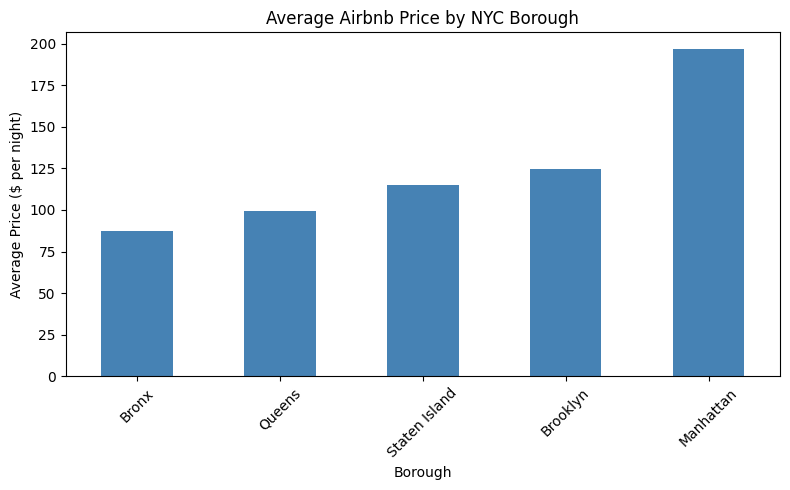

In [55]:
# average price per borough, sorted so the chart reads low-to-high
avg_price_by_borough = df.groupby("neighbourhood_group")["price"].mean().sort_values()

plt.figure(figsize=(8, 5))
avg_price_by_borough.plot(kind="bar", color="steelblue")

# title and axis labels are required by the rubric for every visualization
plt.title("Average Airbnb Price by NYC Borough")
plt.xlabel("Borough")
plt.ylabel("Average Price ($ per night)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


**Visualization Interpretation**

This bar chart categorizes the Airbnb listings by the NYC Borough that the property resides in and then measures the average price of each one.  Manhattan is the alone at the top at almost $200 per night, with the next closest one being Brooklyn at only $125 per night, and the lowest being the Bronx at $85.

## Visualization 2

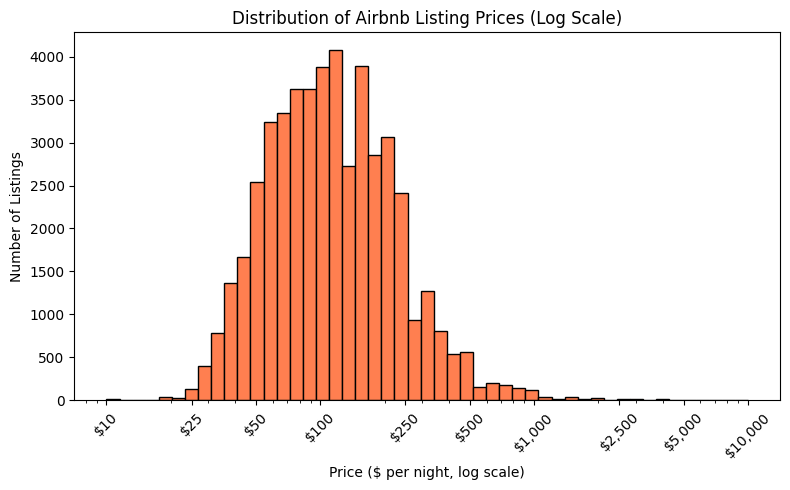

In [56]:
plt.figure(figsize=(8, 5))

bins = np.logspace(np.log10(df["price"].min()), np.log10(df["price"].max()), 50)
plt.hist(df["price"], bins=bins, color="coral", edgecolor="black")
plt.xscale("log")

# override the default power-of-10 tick labels with actual dollar amounts
tick_values = [10, 25, 50, 100, 250, 500, 1000, 2500, 5000, 10000]
plt.xticks(tick_values, [f"${v:,}" for v in tick_values], rotation=45)

plt.title("Distribution of Airbnb Listing Prices (Log Scale)")
plt.xlabel("Price ($ per night, log scale)")
plt.ylabel("Number of Listings")
plt.tight_layout()
plt.show()


**Visual Interpritation**
The listings peak at over 4,000 around the $125 range. It gradually tapers off on both sides, with a long right-skewed tail stretching all the way to $10,000.

## Visualization 3

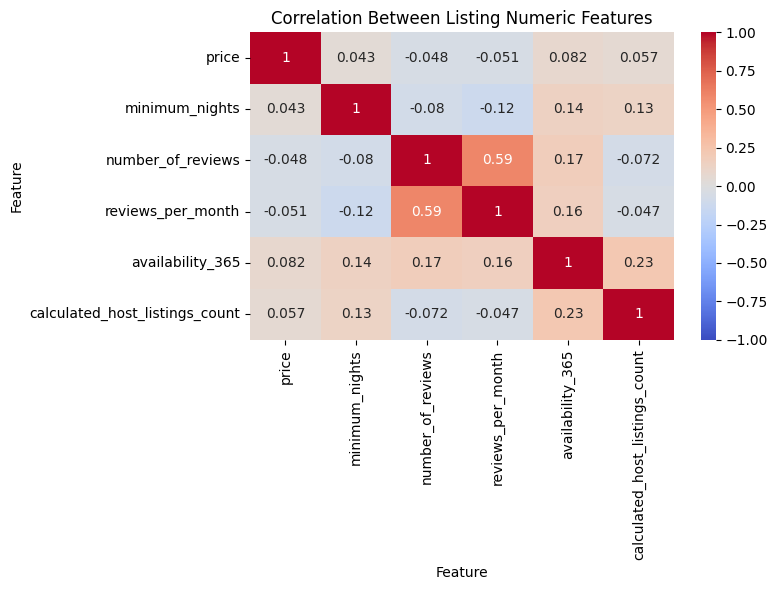

In [57]:
# recompute the correlation matrix for the key numeric columns
numeric_cols = ["price", "minimum_nights", "number_of_reviews",
                 "reviews_per_month", "availability_365",
                 "calculated_host_listings_count"]
corr_matrix = df[numeric_cols].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", vmin=-1, vmax=1)

plt.title("Correlation Between Listing Numeric Features")
plt.xlabel("Feature")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()


**Visualization Interpretation**
The only 2 Features with a decent correlation is number_of_reviews and reviews_per_month. Which makes sense considering they are basically measuring the same thing. The only other correlation above +-0.2 is availability_365 and calculated_host_listings_count. Which would indicate professional hosts/real estate investments specifically made for Airbnb.

In [58]:
# check whether the large group of never-reviewed listings (missing reviews_per_month)
# is masking a real price/review relationship, or whether price is genuinely
# uncorrelated with review activity regardless

# correlation using all listings (never-reviewed listings count as 0 reviews/month)
corr_all = df["price"].corr(df["reviews_per_month"])
print("Correlation, all listings:", corr_all)

# correlation using only listings that have received at least one review
reviewed_only = df[df["number_of_reviews"] > 0]
corr_reviewed_only = reviewed_only["price"].corr(reviewed_only["reviews_per_month"])
print("Correlation, reviewed listings only:", corr_reviewed_only)

print("Never-reviewed listings:", len(df) - len(reviewed_only), "out of", len(df))


Correlation, all listings: -0.050530549334263625
Correlation, reviewed listings only: -0.030574988868899314
Never-reviewed listings: 10051 out of 48884


# Summary & Interpretation

**What we learned**
* Price varies alot from borough to borough. Manahatten averages $197 per night, while the Bronx is only averaging $88 per night.  That's more then a 2 times difference. 
* Room type price operates in a consistant and predictable pattern of Entire home/apt > Private room > Shared room (e.g. in Manhattan: $249 vs $117 vs $89). 
* The overall price distribution is right-skewed, meaning most listings cluster between $70 and $170 per night, peaking around $110 to $126. And then a long tail of high priced outliers all the way up to $10,000.

**Interesting Insight**
* Price is essentially uncorrelated with review activity (-0.05). 
* Roughly 21% of listings (10,051 of 48,884) have never received a review. I checked whether this large group of "zero" values was masking a real price-review relationship by recalculating the correlation using only reviewed listings, but the result was nearly identical (-0.031 vs. -0.051 for the full dataset), confirming that price and review frequency are genuinely uncorrelated rather than an artifact of unreviewed listings.

**Limitations / Assumptions**
* I assumed that the 11 listings that were priced at $0, were data errors and dropped them. But they could have been a free promotional listing.
* I filled a small number of missing host_name values with "Unknown" rather than dropping those rows, an arbitrary but low-impact choice (<0.1% of rows)
* This dataset is from 2019. New York Cities Airbnb and short term rental market could have changed dramatically since then. 

**Surprising**
* It's somewhat counterintuitive that price doesn't correlate with review volume. I would have expected well-reviewed listings to command higher prices. But the data tells a different story.

